# Computing layer thickness in a rotated rectangle
This notebook explores the computation of layer thicknesses in a geometric model of a layered cylinder cut perpendicular to the main axes, with an offset relative to the centre. 

While the radial thickness of the layers is constant, the actual thickness within the cut differs and has to be calculated from the knowledge of the cut width relative to the cylinder width.

## 1. Importing libraries
The first code cell imports the required Python libraries:
- `numpy` for numerical operations
- `matplotlib.pyplot` for plotting and visualization

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.float64(60.00000000000001)

## 2. Initial layer ratio calculation
This cell defines parameters for the number of layers, thickness, and width, then computes a set of ratios for each layer using a mathematical formula. The results are printed for inspection.

In [3]:
n = 5
t = 0.4
w = 3.79

k = np.sqrt((n**2 * t**2) - (w**2 / 4)) / t
print(k)
ratios = []
inside = 0
for l in range(1, n+1):
    if l <= k: 
        ratios.append(0)
        continue
    alpha = np.arccos(k / l)
    # print(alpha)
    x = np.sin(alpha) * l * t
    r = (x - inside) * 2 / w
    ratios.append(r)
    inside = x

print(ratios)

1.5987788308581035
[0, np.float64(0.253641477967604), np.float64(0.28218649680510355), np.float64(0.238123112463317), np.float64(0.22604891276397546)]


## 3. Alternative ratio calculation
This cell provides an alternative approach to calculating the ratios for each layer, using a different formula for the $x$ value. The results are printed for comparison.

In [ ]:
k = np.sqrt((n**2 * t**2) - (w**2 / 4)) / t
print(k)
ratios = []
inside = 0
for l in range(1, n+1):
    if l <= k: 
        ratios.append(0)
        continue
    x = np.sqrt((l*t)**2 - (k*t)**2)
    r = (x - inside) * 2 / w
    ratios.append(r)
    inside = x

print(ratios)

3.3071891388307386
[0, 0, 0, np.float64(0.6), np.float64(0.3999999999999999)]


## 4. Sweeping width parameter and visualizing ratios
This cell sweeps the width parameter $w$ over a range of values, recalculates the ratios for each layer, and stores the results in a matrix. It then plots the ratio for each layer as a function of $w$ to visualize how the ratios change.

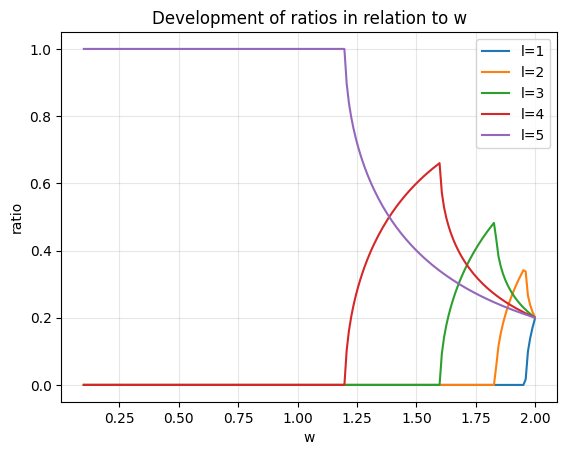

In [ ]:
# Sweep w and compute ratios for each l
w_values = np.linspace(0.1, 2 * n * t * 0.999, 200)  # keep inside valid domain
ratio_matrix = np.zeros((len(w_values), n))

for i, wv in enumerate(w_values):
    kv = np.sqrt((n**2 * t**2) - (wv**2 / 4)) / t
    inside_v = 0.0
    row = []
    for lv in range(1, n + 1):
        if lv <= kv:
            row.append(0.0)
            continue
        xv = np.sqrt((lv * t) ** 2 - (kv * t) ** 2)
        rv = (xv - inside_v) * 2 / wv
        row.append(rv)
        inside_v = xv
    ratio_matrix[i, :] = row

# Plot ratio_l(w) for l = 1..n
for lv in range(n):
    plt.plot(w_values, ratio_matrix[:, lv], label=f"l={lv+1}")

plt.xlabel("w")
plt.ylabel("ratio")
plt.title("Development of ratios in relation to w")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Normalizing and stacked area chart
This cell normalizes the ratio matrix so that the contributions of all layers sum to 1 for each value of $w$. It then creates a stacked area chart to visualize the normalized contributions of each layer as $w$ varies.

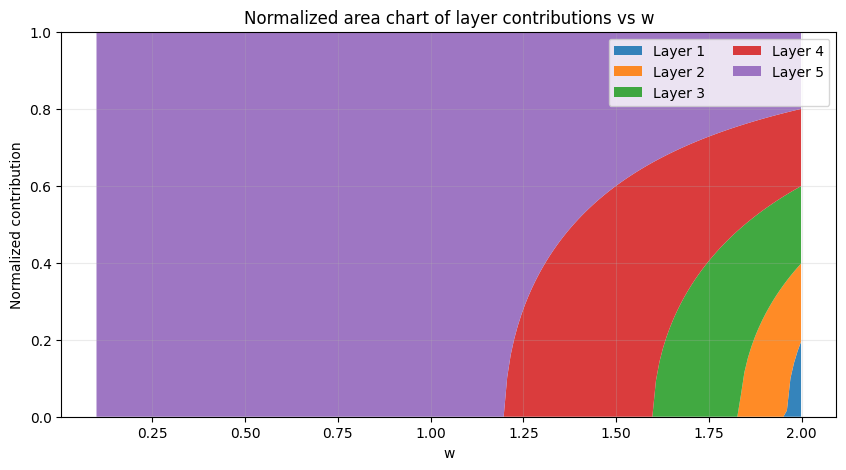

In [35]:
# Normalize each row so contributions sum to 1 (safe for any zero-sum row)
row_sums = ratio_matrix.sum(axis=1, keepdims=True)
normalized_ratio_matrix = np.divide(
    ratio_matrix,
    row_sums,
    out=np.zeros_like(ratio_matrix),
    where=row_sums != 0
)

# Stacked normalized area chart
plt.figure(figsize=(10, 5))
plt.stackplot(
    w_values,
    normalized_ratio_matrix.T,
    labels=[f"Layer {idx}" for idx in range(1, n + 1)],
    alpha=0.9
)

plt.xlabel("w")
plt.ylabel("Normalized contribution")
plt.title("Normalized area chart of layer contributions vs w")
plt.ylim(0, 1)
plt.legend(loc="upper right", ncol=2)
plt.grid(True, alpha=0.25)
plt.show()

## 6. Actual layer thickness visualization
This cell converts the normalized ratios back to actual layer thickness values and visualizes them using a stacked area chart, showing how the thickness of each layer changes as $w$ varies.

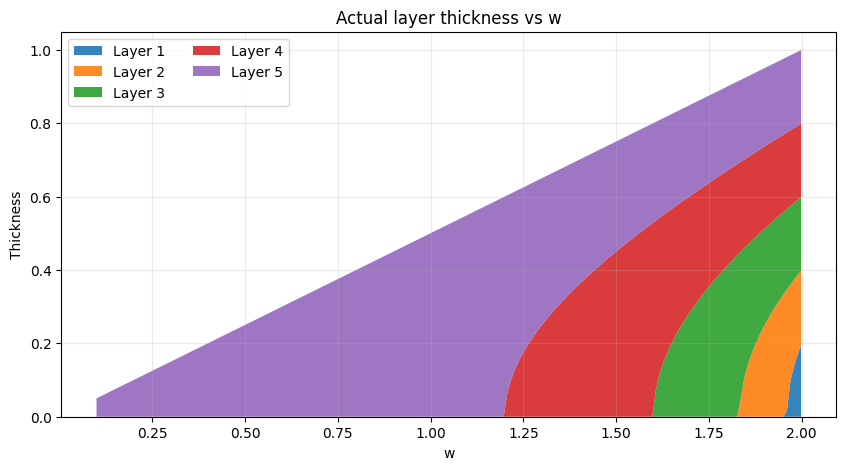

In [37]:
# Convert ratios back to actual thickness:
# ratio = thickness * 2 / w  =>  thickness = ratio * w / 2
thickness_matrix = ratio_matrix * (w_values[:, None] / 2)

# Stacked area chart of actual layer thickness
plt.figure(figsize=(10, 5))
plt.stackplot(
    w_values,
    thickness_matrix.T,
    labels=[f"Layer {idx}" for idx in range(1, n + 1)],
    alpha=0.9
)

plt.xlabel("w")
plt.ylabel("Thickness")
plt.title("Actual layer thickness vs w")
plt.legend(loc="upper left", ncol=2)
plt.grid(True, alpha=0.25)
plt.show()


## 7. (empty/placeholder cell)
This cell is currently empty and may be used for further analysis or notes.